# Database Benchmark Analysis

This notebook analyzes and visualizes the results from comprehensive database benchmarking tests across MySQL, PostgreSQL, MongoDB, and Redis.

## Overview
- **Objective**: Compare performance of different database systems under various conditions
- **Databases Tested**: MySQL, PostgreSQL, MongoDB, Redis
- **Data Scales**: 500K, 1M, 10M records
- **Operations**: SELECT/FIND/GET (read), INSERT/SET (create), UPDATE (modify), DELETE/DEL (remove)
- **Trials**: 3 trials per benchmark scenario
- **Scenario count**: 24+ distinct scenarios (meets Grade 4.0 requirements)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import os
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Color palettes
DB_COLORS = {
    'mysql':      '#00758f',
    'postgresql': '#336791',
    'mongodb':    '#13aa52',
    'redis':      '#dc382d',
}

OP_COLORS = {
    'read':   '#2ecc71',
    'create': '#3498db',
    'update': '#f39c12',
    'delete': '#e74c3c',
}

print('Libraries loaded.')

Libraries loaded.


## 2. Load Benchmark Results

In [2]:
results_dir = Path('../results')

csv_files = sorted(results_dir.glob('benchmark_results_*.csv'))
json_files = sorted(results_dir.glob('benchmark_results_*.json'))

if not csv_files:
    raise FileNotFoundError('No CSV result files found in ../results/')

latest_csv = csv_files[-1]
print(f'Loading: {latest_csv.name}')
df_raw = pd.read_csv(latest_csv)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

# Normalize operation names to CRUD categories
READ_OPS   = {'select', 'find', 'get'}
CREATE_OPS = {'insert', 'insertone', 'set'}
UPDATE_OPS = {'update', 'updateone'}
DELETE_OPS = {'delete', 'deleteone', 'del'}

def normalize_op(op):
    op_lower = str(op).lower()
    if op_lower in READ_OPS:   return 'read'
    if op_lower in CREATE_OPS: return 'create'
    if op_lower in UPDATE_OPS: return 'update'
    if op_lower in DELETE_OPS: return 'delete'
    return op_lower

df_raw['crud_op'] = df_raw['operation'].apply(normalize_op)

# Remove extreme outliers (QPS < 10 or > 1_000_000)
df = df_raw[(df_raw['queries_per_second'] >= 10) & (df_raw['queries_per_second'] <= 1_000_000)].copy()
print(f'After outlier filter: {len(df)} rows (removed {len(df_raw)-len(df)})')

print('\nUnique operations:', df['operation'].unique())
print('CRUD categories:  ', df['crud_op'].unique())
print('Databases:        ', df['database'].unique())
print('Data scales:      ', sorted(df['data_scale'].unique()))

Loading: benchmark_results_20260416_174804.csv
Shape: (720, 11)
Columns: ['database', 'entity', 'operation', 'batch_size', 'data_scale', 'trial', 'num_queries', 'total_time_ms', 'avg_time_per_op_ms', 'queries_per_second', 'with_index']
After outlier filter: 720 rows (removed 0)

Unique operations: <StringArray>
[   'select',    'insert',    'update',    'delete',      'find', 'insertOne',
 'updateOne', 'deleteOne',       'get',       'set',       'del']
Length: 11, dtype: str
CRUD categories:   <StringArray>
['read', 'create', 'update', 'delete']
Length: 4, dtype: str
Databases:         <StringArray>
['mysql', 'postgresql', 'mongodb', 'redis']
Length: 4, dtype: str
Data scales:       [np.int64(500000), np.int64(1000000), np.int64(10000000)]


## 3. Summary Statistics

In [3]:
print('=' * 70)
print('PERFORMANCE SUMMARY BY DATABASE AND CRUD OPERATION')
print('=' * 70)

summary = df.groupby(['database', 'crud_op'])['queries_per_second'].agg(['mean', 'std', 'count']).round(1)
print(summary.to_string())

print('\n' + '=' * 70)
print('SCENARIO COUNT (database × operation × data_scale)')
print('=' * 70)
scenario_count = df.groupby(['database', 'operation'])['queries_per_second'].count()
print(scenario_count)
total_scenarios = df[['database', 'entity', 'operation']].drop_duplicates().shape[0]
print(f'\nTotal distinct scenarios: {total_scenarios}')

PERFORMANCE SUMMARY BY DATABASE AND CRUD OPERATION
                      mean     std  count
database   crud_op                       
mongodb    create   6441.9   216.9     27
           delete   5488.9   410.2     27
           read     6234.9   220.5     27
           update   6020.6   304.7     27
mysql      create   7706.3   670.1     54
           delete   8171.2   414.6     45
           read     6865.2   608.0    108
           update   8088.6   450.7     45
postgresql create   5909.8  1139.3     54
           delete   7576.2   360.5     45
           read     7340.5   390.3    108
           update   5688.5  1534.6     45
redis      create   8243.1   376.8     36
           delete   8617.1   575.7     36
           read     8616.3   484.4     36

SCENARIO COUNT (database × operation × data_scale)
database    operation
mongodb     deleteOne     27
            find          27
            insertOne     27
            updateOne     27
mysql       delete        45
            inse

## 4. Visualizations

### 4.1 Average QPS by Database (all operations)

/var/folders/yh/wcj04z8j4cx217b0cwf7b1_w0000gp/T/ipykernel_87720/756577522.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.upper() for d in db_qps.index])


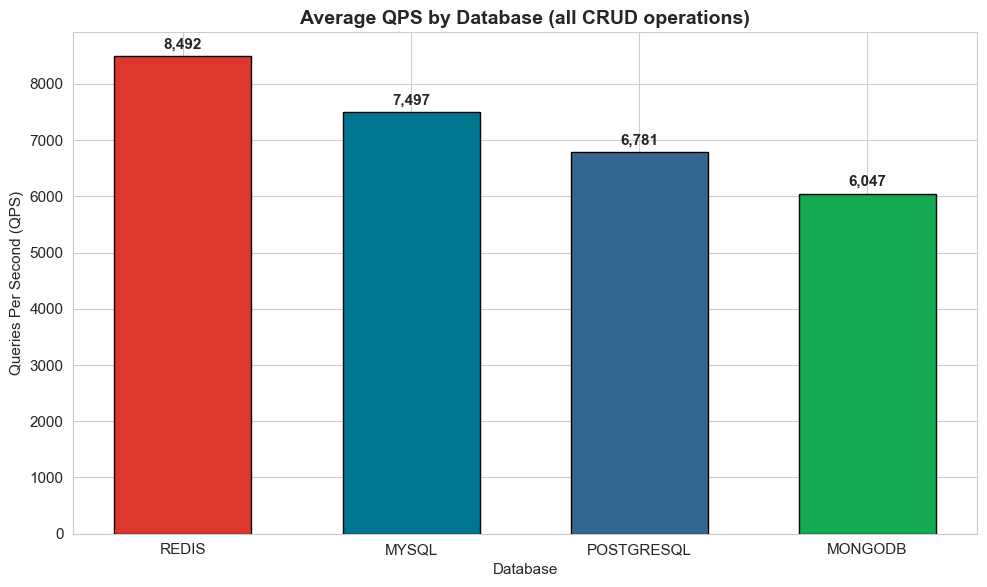

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

db_qps = df.groupby('database')['queries_per_second'].mean().sort_values(ascending=False)
bars = ax.bar(
    db_qps.index,
    db_qps.values,
    color=[DB_COLORS.get(db, '#999') for db in db_qps.index],
    edgecolor='black', width=0.6
)

for bar, val in zip(bars, db_qps.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(db_qps)*0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Average QPS by Database (all CRUD operations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.set_xticklabels([d.upper() for d in db_qps.index])
plt.tight_layout()
plt.savefig('chart_01_avg_qps_by_db.png', dpi=150)
plt.show()

### 4.2 CRUD Operation Comparison per Database

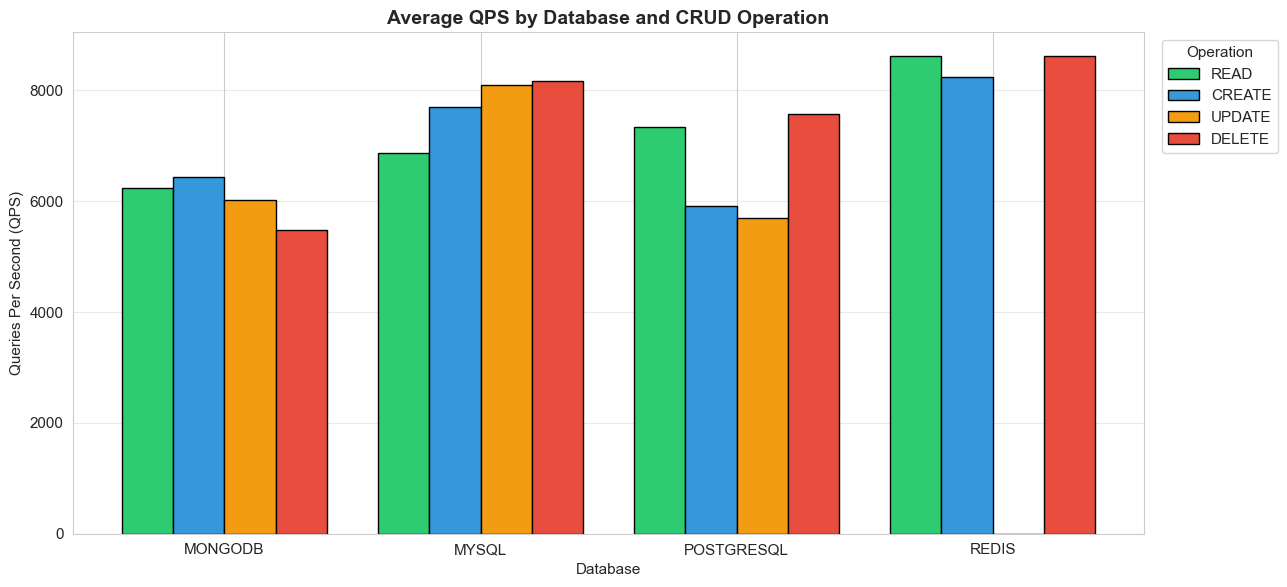

In [5]:
crud_order = ['read', 'create', 'update', 'delete']
existing_ops = [op for op in crud_order if op in df['crud_op'].unique()]

pivot = df.groupby(['database', 'crud_op'])['queries_per_second'].mean().unstack(fill_value=0)
pivot = pivot.reindex(columns=[c for c in crud_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(pivot.index))
width = 0.2
offsets = np.linspace(-(len(existing_ops)-1)/2, (len(existing_ops)-1)/2, len(existing_ops)) * width

for i, op in enumerate(existing_ops):
    if op not in pivot.columns:
        continue
    bars = ax.bar(x + offsets[i], pivot[op], width, label=op.upper(),
                  color=OP_COLORS.get(op, '#aaa'), edgecolor='black')

ax.set_title('Average QPS by Database and CRUD Operation', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in pivot.index])
ax.legend(title='Operation', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_02_crud_by_db.png', dpi=150)
plt.show()

### 4.3 Performance by Data Scale per Database

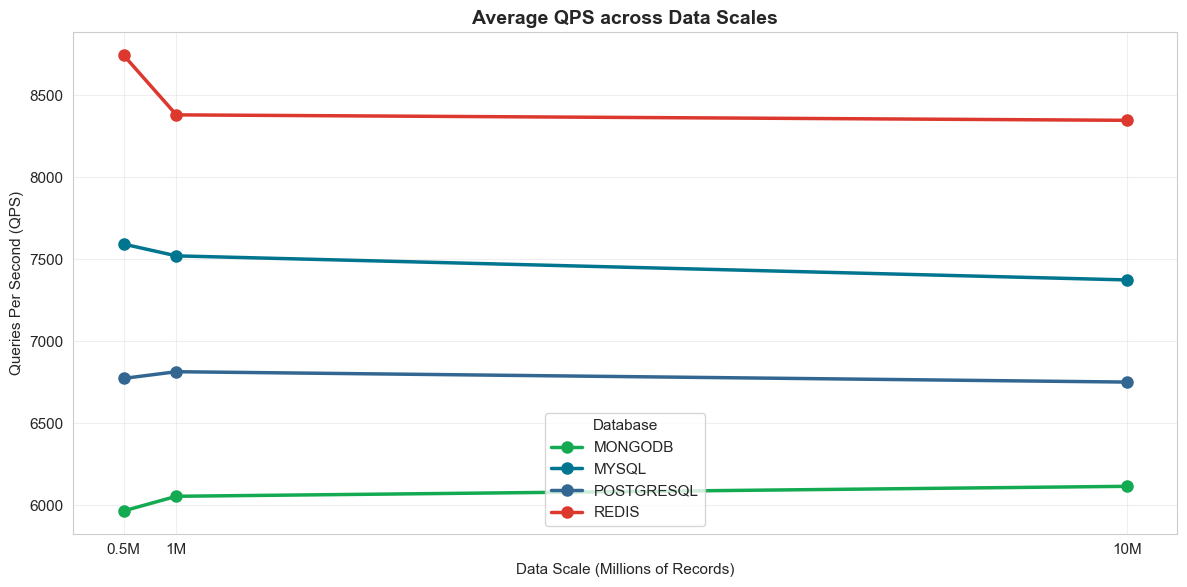

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for db in sorted(df['database'].unique()):
    db_data = df[df['database'] == db].groupby('data_scale')['queries_per_second'].mean().sort_index()
    ax.plot(db_data.index / 1_000_000, db_data.values,
            marker='o', label=db.upper(), linewidth=2.5, markersize=8,
            color=DB_COLORS.get(db))

ax.set_title('Average QPS across Data Scales', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Data Scale (Millions of Records)')
ax.set_xticks([0.5, 1.0, 10.0])
ax.set_xticklabels(['0.5M', '1M', '10M'])
ax.legend(title='Database', loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_03_scale_impact.png', dpi=150)
plt.show()

### 4.4 Data Scale Impact per CRUD Operation

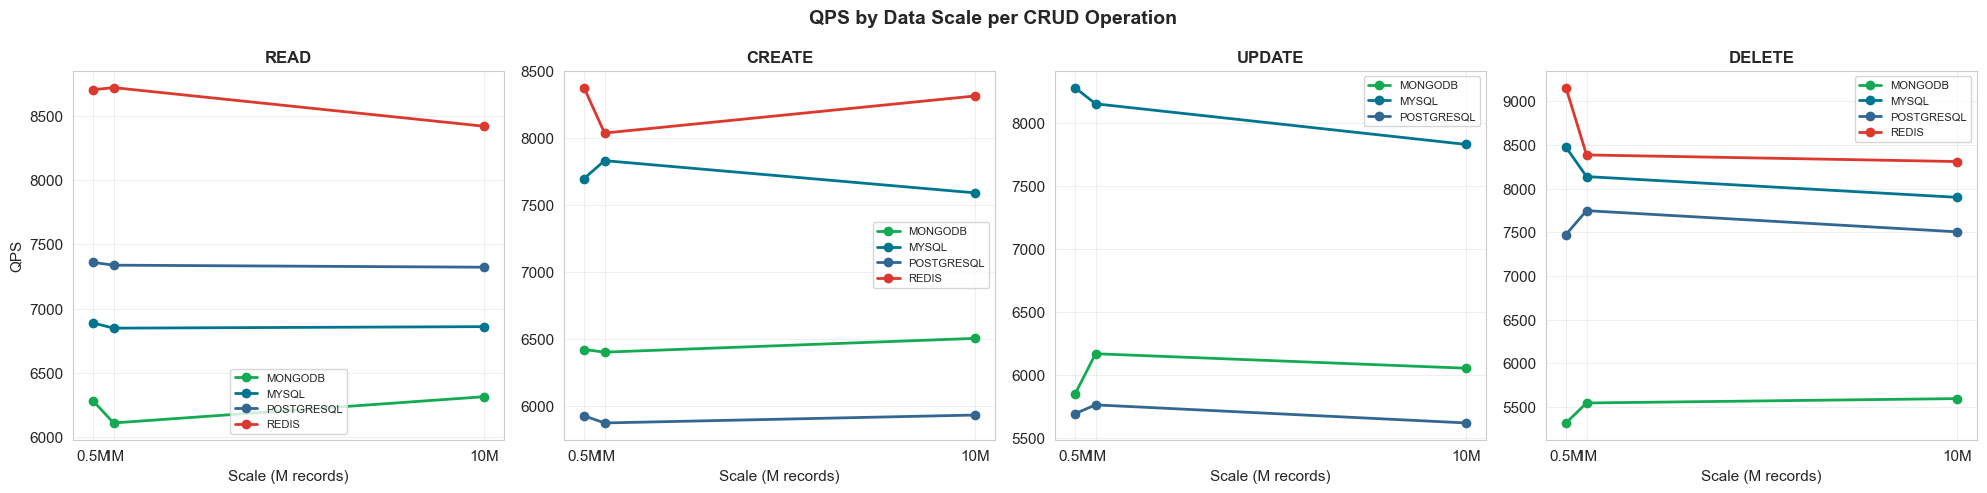

In [7]:
ops_present = [op for op in crud_order if op in df['crud_op'].unique()]
n_ops = len(ops_present)
fig, axes = plt.subplots(1, n_ops, figsize=(5*n_ops, 5), sharey=False)
if n_ops == 1:
    axes = [axes]

for ax, op in zip(axes, ops_present):
    op_data = df[df['crud_op'] == op]
    for db in sorted(op_data['database'].unique()):
        d = op_data[op_data['database'] == db].groupby('data_scale')['queries_per_second'].mean().sort_index()
        ax.plot(d.index / 1_000_000, d.values, marker='o', label=db.upper(),
                linewidth=2, color=DB_COLORS.get(db))
    ax.set_title(f'{op.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Scale (M records)')
    ax.set_ylabel('QPS' if op == ops_present[0] else '')
    ax.set_xticks([0.5, 1.0, 10.0])
    ax.set_xticklabels(['0.5M', '1M', '10M'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('QPS by Data Scale per CRUD Operation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_scale_per_crud.png', dpi=150)
plt.show()

### 4.5 Index Impact Analysis (MySQL & PostgreSQL — SELECT only)

Average QPS (SELECT) — Index Impact:
            Without Index  With Index
database                             
mysql              6890.2      6840.3
postgresql         7392.2      7288.8

% change with index:
  MYSQL: -0.7%
  POSTGRESQL: -1.4%


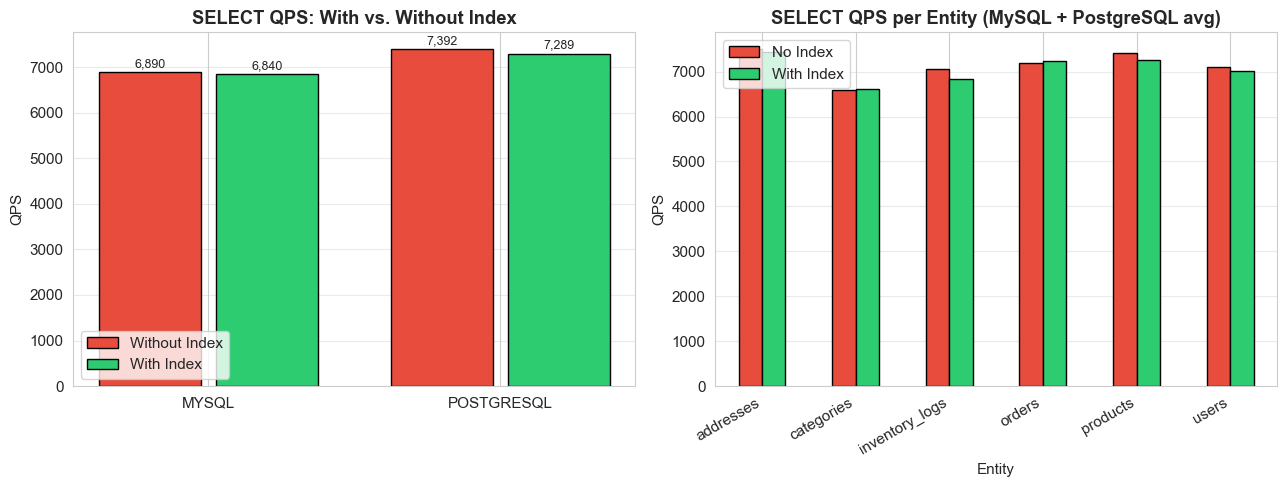

In [8]:
sql_select = df[
    df['database'].isin(['mysql', 'postgresql']) &
    (df['crud_op'] == 'read')
].copy()

if sql_select.empty:
    print('No SQL SELECT data available for index analysis.')
else:
    index_summary = sql_select.groupby(['database', 'with_index'])['queries_per_second'].mean().unstack()
    index_summary.columns = ['Without Index', 'With Index']
    print('Average QPS (SELECT) — Index Impact:')
    print(index_summary.round(1))
    pct = ((index_summary['With Index'] - index_summary['Without Index']) /
           index_summary['Without Index'] * 100)
    print('\n% change with index:')
    for db, v in pct.items():
        sign = '+' if v >= 0 else ''
        print(f'  {db.upper()}: {sign}{v:.1f}%')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    ax = axes[0]
    x = np.arange(len(index_summary))
    bars1 = ax.bar(x - 0.2, index_summary['Without Index'], 0.35,
                   label='Without Index', color='#e74c3c', edgecolor='black')
    bars2 = ax.bar(x + 0.2, index_summary['With Index'], 0.35,
                   label='With Index', color='#2ecc71', edgecolor='black')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
    ax.set_title('SELECT QPS: With vs. Without Index', fontweight='bold')
    ax.set_ylabel('QPS')
    ax.set_xticks(x)
    ax.set_xticklabels([d.upper() for d in index_summary.index])
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

    # Per entity boxplot for both DBs
    ax2 = axes[1]
    entity_idx = sql_select.groupby(['entity', 'with_index'])['queries_per_second'].mean().unstack()
    entity_idx.columns = ['No Index', 'With Index']
    entity_idx.plot(kind='bar', ax=ax2, color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax2.set_title('SELECT QPS per Entity (MySQL + PostgreSQL avg)', fontweight='bold')
    ax2.set_ylabel('QPS')
    ax2.set_xlabel('Entity')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.4)
    plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig('chart_05_index_impact.png', dpi=150)
    plt.show()

### 4.6 Heatmap: Average QPS — Database × CRUD Operation

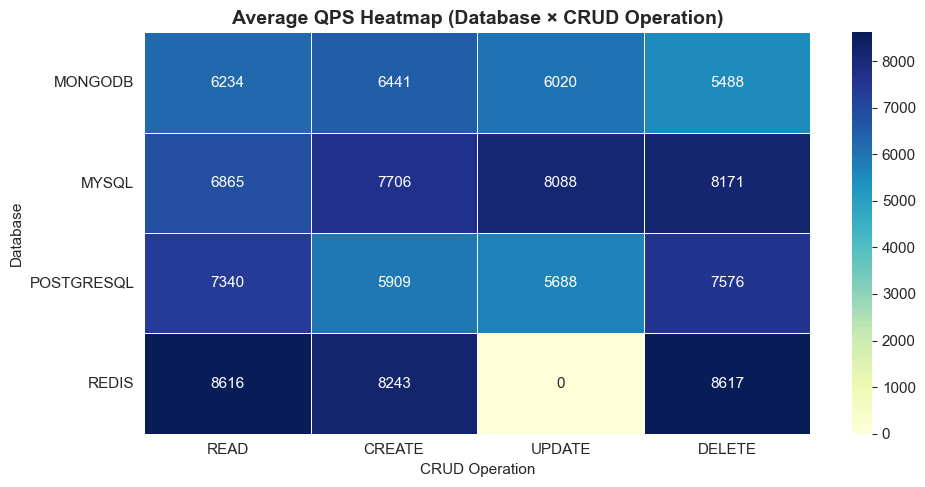

In [9]:
pivot_heat = df.groupby(['database', 'crud_op'])['queries_per_second'].mean().unstack(fill_value=0)
pivot_heat = pivot_heat.reindex(columns=[c for c in crud_order if c in pivot_heat.columns])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_heat.astype(int), annot=True, fmt='d',
    cmap='YlGnBu', ax=ax, linewidths=0.5,
    annot_kws={'size': 11}
)
ax.set_title('Average QPS Heatmap (Database × CRUD Operation)', fontsize=14, fontweight='bold')
ax.set_xlabel('CRUD Operation')
ax.set_ylabel('Database')
ax.set_xticklabels([c.upper() for c in pivot_heat.columns], rotation=0)
ax.set_yticklabels([d.upper() for d in pivot_heat.index], rotation=0)
plt.tight_layout()
plt.savefig('chart_06_heatmap_crud.png', dpi=150)
plt.show()

### 4.7 Variability (Coefficient of Variation) per Database

/var/folders/yh/wcj04z8j4cx217b0cwf7b1_w0000gp/T/ipykernel_87720/3480800950.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[d.upper() for d in db_order], patch_artist=True, notch=False)


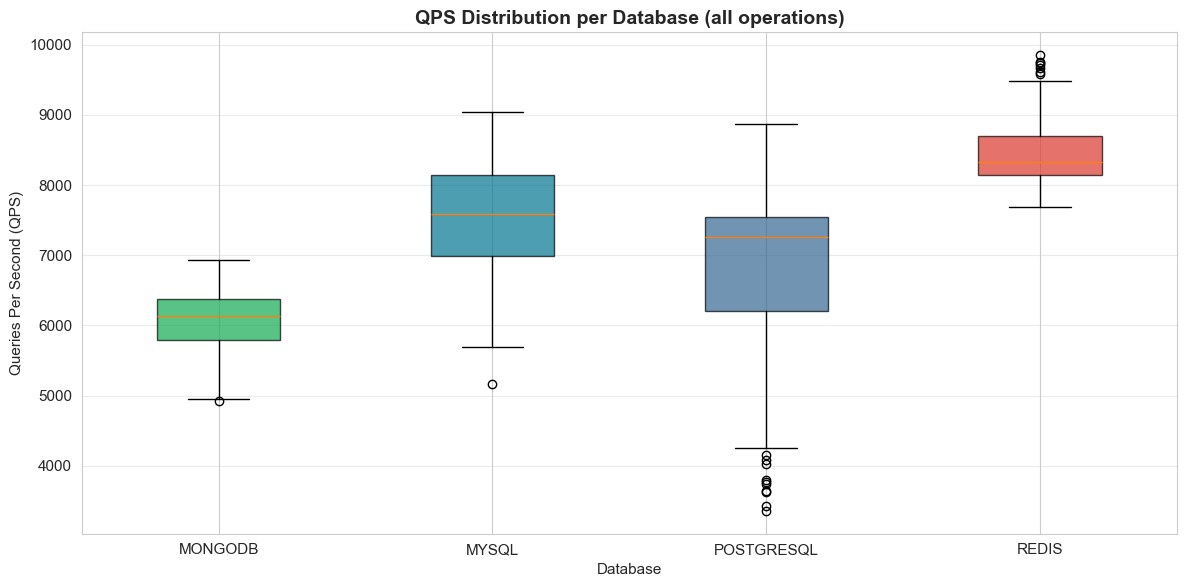

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

db_order = sorted(df['database'].unique())
data_to_plot = [df[df['database'] == db]['queries_per_second'].values for db in db_order]

bp = ax.boxplot(data_to_plot, labels=[d.upper() for d in db_order], patch_artist=True, notch=False)
for patch, db in zip(bp['boxes'], db_order):
    patch.set_facecolor(DB_COLORS.get(db, '#aaa'))
    patch.set_alpha(0.7)

ax.set_title('QPS Distribution per Database (all operations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_07_boxplot_db.png', dpi=150)
plt.show()

## 5. Key Findings

In [11]:
print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)

# 1. Overall ranking
print('\n1. OVERALL DATABASE RANKING (avg QPS all operations):')
ranking = df.groupby('database')['queries_per_second'].agg(['mean','std']).sort_values('mean', ascending=False)
for i, (db, row) in enumerate(ranking.iterrows(), 1):
    print(f'   #{i}. {db.upper()}: {row["mean"]:,.1f} ± {row["std"]:,.1f} QPS')

# 2. Fastest per CRUD
print('\n2. FASTEST DATABASE PER CRUD OPERATION:')
for op in crud_order:
    op_df = df[df['crud_op'] == op]
    if op_df.empty:
        continue
    best_db = op_df.groupby('database')['queries_per_second'].mean().idxmax()
    best_qps = op_df.groupby('database')['queries_per_second'].mean().max()
    print(f'   {op.upper():8s}: {best_db.upper()} ({best_qps:,.1f} QPS)')

# 3. Data scale impact
print('\n3. IMPACT OF DATA SCALE ON QPS:')
scale_perf = df.groupby('data_scale')['queries_per_second'].mean().sort_index()
first, last = scale_perf.iloc[0], scale_perf.iloc[-1]
change = (last - first) / first * 100
for scale, qps in scale_perf.items():
    print(f'   {scale/1e6:.1f}M records: {qps:,.1f} QPS')
print(f'   Change 0.5M → 10M: {change:+.1f}%')

# 4. Index impact
sql_read = df[df['database'].isin(['mysql','postgresql']) & (df['crud_op']=='read')]
if not sql_read.empty:
    print('\n4. INDEX IMPACT (SQL SELECT):')
    for db in ['mysql', 'postgresql']:
        d = sql_read[sql_read['database'] == db]
        no_idx = d[d['with_index'] == False]['queries_per_second'].mean()
        wi_idx = d[d['with_index'] == True]['queries_per_second'].mean()
        chg = (wi_idx - no_idx) / no_idx * 100
        print(f'   {db.upper()}: without={no_idx:,.1f} with={wi_idx:,.1f} ({chg:+.1f}%)')

# 5. Consistency
print('\n5. CONSISTENCY (Coefficient of Variation):')
for db in sorted(df['database'].unique()):
    d = df[df['database'] == db]['queries_per_second']
    cv = d.std() / d.mean() * 100
    label = 'Very Stable' if cv < 15 else ('Moderate' if cv < 30 else 'High Variance')
    print(f'   {db.upper():12s}: CV={cv:.1f}% ({label})')

print('\n' + '=' * 70)

KEY FINDINGS

1. OVERALL DATABASE RANKING (avg QPS all operations):
   #1. REDIS: 8,492.2 ± 512.7 QPS
   #2. MYSQL: 7,497.1 ± 802.2 QPS
   #3. POSTGRESQL: 6,781.0 ± 1,183.2 QPS
   #4. MONGODB: 6,046.6 ± 462.3 QPS

2. FASTEST DATABASE PER CRUD OPERATION:
   READ    : REDIS (8,616.3 QPS)
   CREATE  : REDIS (8,243.1 QPS)
   UPDATE  : MYSQL (8,088.6 QPS)
   DELETE  : REDIS (8,617.1 QPS)

3. IMPACT OF DATA SCALE ON QPS:
   0.5M records: 7,236.0 QPS
   1.0M records: 7,183.9 QPS
   10.0M records: 7,114.5 QPS
   Change 0.5M → 10M: -1.7%

4. INDEX IMPACT (SQL SELECT):
   MYSQL: without=6,890.2 with=6,840.3 (-0.7%)
   POSTGRESQL: without=7,392.2 with=7,288.8 (-1.4%)

5. CONSISTENCY (Coefficient of Variation):
   MONGODB     : CV=7.6% (Very Stable)
   MYSQL       : CV=10.7% (Very Stable)
   POSTGRESQL  : CV=17.4% (Moderate)
   REDIS       : CV=6.0% (Very Stable)



## 6. Export Summary Reports

In [12]:
# Summary by database
summary_export = df.groupby('database').agg(
    avg_qps=('queries_per_second', 'mean'),
    std_qps=('queries_per_second', 'std'),
    avg_time_ms=('avg_time_per_op_ms', 'mean'),
    total_tests=('queries_per_second', 'count'),
).round(4)
summary_export.to_csv('summary_report.csv')
print(f'Summary exported → summary_report.csv')

# Per database CSV files
for db in df['database'].unique():
    db_data = df[df['database'] == db]
    db_data.to_csv(f'{db}_results.csv', index=False)
    print(f'{db.upper()} exported → {db}_results.csv')

# Top performers
top = df.nlargest(20, 'queries_per_second')[[
    'database', 'entity', 'operation', 'crud_op', 'data_scale', 'queries_per_second', 'avg_time_per_op_ms'
]]
top.to_csv('top_performers.csv', index=False)
print(f'Top performers exported → top_performers.csv')

# CRUD summary
crud_summary = df.groupby(['database', 'crud_op', 'data_scale'])['queries_per_second'].agg(['mean','std','count']).round(2)
crud_summary.to_csv('crud_summary.csv')
print(f'CRUD summary exported → crud_summary.csv')

print('\nAll exports complete.')

Summary exported → summary_report.csv
MYSQL exported → mysql_results.csv
POSTGRESQL exported → postgresql_results.csv
MONGODB exported → mongodb_results.csv
REDIS exported → redis_results.csv
Top performers exported → top_performers.csv
CRUD summary exported → crud_summary.csv

All exports complete.
